##Assignment 3 – Neural Network Generalization & Reliability
This notebook implements two models for health-risk prediction:

1. Baseline MLP – used to observe natural overfitting and establish a reference point for generalization performance.

2. Dropout-Regularized MLP – designed to reduce overfitting and produce a more stable, reliable classifier.

## Part A- Pre Analysis & Expectations


1. Accuracy alone is insufficient

- Dataset has 4 classes with Tier 0 as the majority
- High accuracy could occur by predicting the majority class frequently
- Misclassifying high-risk patients (Tier 3) as low-risk is much more harmful.

2. Evaluation Metric
- Use macro Precision, Recall, and F1-score
- Treats each class equally
- Highlights performance on minority/high-risk tiers
- This ismportant for health-risk prediction where false negatives are critica.


3. With 18 features and only 1500 samples, MLP is prone to overfitting.  This is because as
training loss decreases, validation loss increases and there is a widening gap between training and validation accuracy.

   **Overfitting Control**

  - Dropout was selected as regularization strategy for controlled comparison
  - Randomly deactivates neurons during training
  - Reduces co-adaptation and improves generalization
   



##Part B – Data Preparation
The following were examined, after loading the dataset.

1. Missing data was examined- No missing data
2. Data Imbalance was checked
3. Train/Validation/Test Split
4. Feature Scaling- to ensure stable gradient updates and prevents large‑scale features (e.g., triglycerides) from dominating training.

In [ ]:
# Load Data & Check Missing Values
import pandas as pd
df = pd.read_csv("Health_Risk_Tiers.csv")
df.head()



,Age,BMI,SBP,DBP,Resting_HR,HbA1c,LDL,HDL,Triglycerides,CRP,WBC,eGFR,Creatinine,Activity_Score,Sleep_Hours,LDL_Alt,CRP_Log,Random_Index,Risk_Tier
0,65,29.0,138,78,67,6.21,109,68,92,0.94,7.44,100,0.68,94,8.33,97,0.677,0.453,0
1,22,22.2,122,80,82,5.28,116,79,63,0.37,5.51,99,1.34,89,6.69,116,0.344,1.589,0
2,44,29.9,124,70,75,6.42,132,61,164,3.82,10.03,105,0.62,86,6.86,116,1.645,0.295,0
3,51,19.4,129,68,79,6.10,142,26,211,2.37,6.34,86,1.11,39,6.08,133,1.235,-2.478,2
4,55,32.6,117,73,73,4.90,110,59,40,1.90,7.45,97,0.88,46,6.94,107,1.149,1.951,0


In [ ]:
# Check missing Values
df.isna().sum()

,0
Age,0
BMI,0
SBP,0
DBP,0
Resting_HR,0
HbA1c,0
LDL,0
HDL,0
Triglycerides,0
CRP,0


In [ ]:
df.isna().sum()

,0
Age,0
BMI,0
SBP,0
DBP,0
Resting_HR,0
HbA1c,0
LDL,0
HDL,0
Triglycerides,0
CRP,0


### Check for Class Imbalance



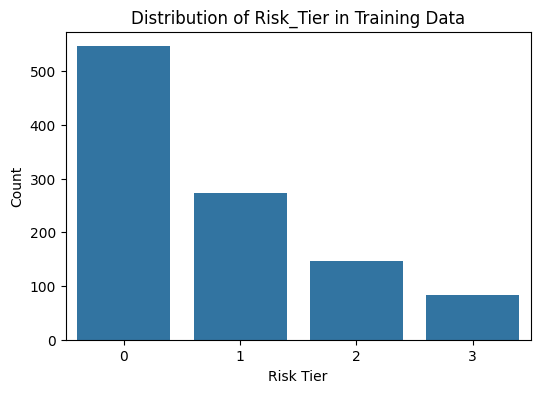

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is available, though it's already in the kernel state
# import pandas as pd
# df = pd.read_csv("Health_Risk_Tiers.csv")

# Re-add the train/validation/test split to define y_train
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Risk_Tier"])
y = df["Risk_Tier"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribution of Risk_Tier in Training Data')
plt.xlabel('Risk Tier')
plt.ylabel('Count')
plt.show()

**Class Imbalance**

In classification problems, especially with multiple classes, it's important to check if the classes are evenly distributed. An imbalance can lead to a model that performs well on the majority class but poorly on minority classes. The graph shows the distribution of the risk_ tiers in the training data.

In [ ]:
# Train/Validation/Test Split

from sklearn.model_selection import train_test_split

X = df.drop(columns=["Risk_Tier"])
y = df["Risk_Tier"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


Stratified split: 70% training, 15% validation, and 15% test, to preserve class proportions.

## Part C – Baseline Neural Network
1.Feature Scaling

2.Build Baseline MLP

3.Train Baseline Model

4.Training and validation Learning Curves

5.Overfitting, Underfitting Or good fit

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
# Feature Scaling
import numpy as np

print("Mean of X_train_scaled:", np.mean(X_train_scaled, axis=0))
print("Standard Deviation of X_train_scaled:", np.std(X_train_scaled, axis=0))

Mean of X_train_scaled: [-1.64101537e-16 -4.04332652e-16 -1.97936905e-16  1.52259158e-16
 -1.48875621e-16  3.53579599e-16 -1.87786294e-16  9.13554946e-17
 -1.87786294e-16 -8.62801893e-17  1.96245137e-16  2.14008705e-16
 -9.81225683e-17  1.77635684e-17  2.94367705e-16 -2.19084010e-16
  4.56777473e-17 -3.38353684e-17]
Standard Deviation of X_train_scaled: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


I applied StandardScaler. After scaling, the mean is zero and the standard deviation is one for all features, which helps stabilize neural network training

In [ ]:
# Build Baseline MLP
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_scaled.shape[1]
num_classes = y.nunique()

baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


This is my baseline MLP with two hidden layers: 64 and 32 units. No regularization.


In [ ]:
# Train Baseline Model
history_base = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)


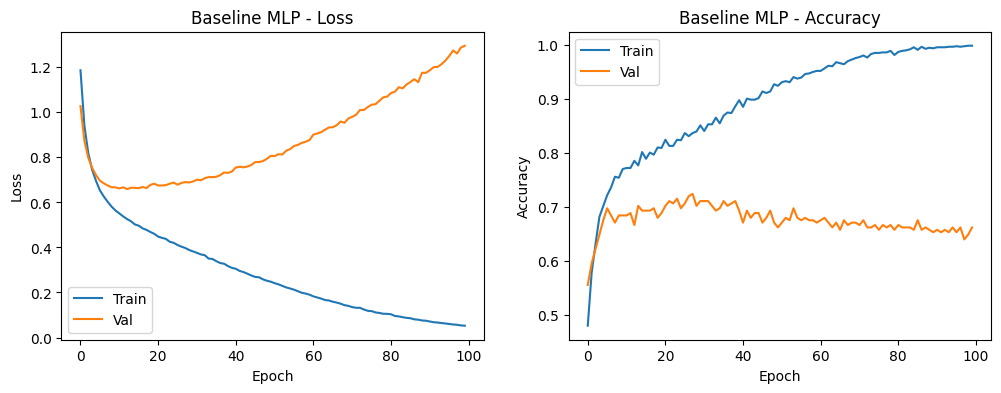

In [ ]:
# Plot Training and validation Learning Curves
import matplotlib.pyplot as plt

def plot_learning_curves(history, title_prefix="Model"):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_learning_curves(history_base, "Baseline MLP")


1. Training loss decreases continuously
2. Validation loss increases after some epochs
3. Training accuracy becomes very high, while validation accuracy plateaus
This means the model was memorizing the training data instead of learning general patterns.



# Fittness Assessment- Underfitting, good Fit and Overfitting

 1. **Underfitting** is not strongly observed,both training and validation loss remain high, both accuracies are low and model fails to learn patterns.

 2. **Overfitting - Baseline MLP**

-  Training loss is very low, but    validation loss is high or increasing.

-  Training accuracy is very high, but validation accuracy is lower.

-  Large gap between training and validation performance.

The Model memorizes training data but does not generalize well.

3. **Good Fit -Regularized MLP with Dropout**

-Training and validation loss are both low and close to each other.

- Validation loss is stable there is no big increase.

- Training and validation accuracy are close.

The model generalizes well to new data



## Part D – Controlled Regularization Experiment
1. Build regularized Mlp - Dropout
2. Train regularized Model
3. Compare learning Curve

In [ ]:

# Build regularized Mlp - Dropout
reg_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

reg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Next, I trained the same architecture but added Dropout with a rate of 0.4 in both hidden layers.”

In [ ]:
# Train regularized Model
history_reg = reg_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)


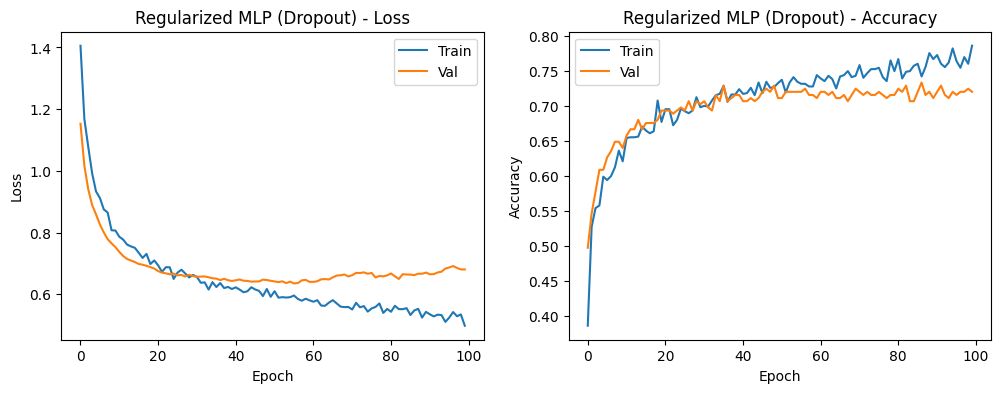

In [ ]:
# Compare learning Curve
plot_learning_curves(history_reg, "Regularized MLP (Dropout)")


1. Validation loss is more stable over epochs
2. Gap between training and validation accuracy is smaller
3. Training improves without large divergence
This shows improved generalization.



##Part E – Final Evaluation & Error Analysis
1. Select best model based on validation performance
2. Test set evaluation
3. Confusion Matrix
4. Error Analysis

In [ ]:
# Select best model based on validation performance
best_model = reg_model  # or baseline_model


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_test_pred_proba = best_model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

print(f"Macro Precision: {classification_report(y_test, y_test_pred, output_dict=True)['macro avg']['precision']:.3f}")
print(f"Macro Recall: {classification_report(y_test, y_test_pred, output_dict=True)['macro avg']['recall']:.3f}")
print(f"Macro F1-Score: {classification_report(y_test, y_test_pred, output_dict=True)['macro avg']['f1-score']:.3f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Macro Precision: 0.715
Macro Recall: 0.708
Macro F1-Score: 0.711


In [ ]:
#Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

y_test_pred_proba = best_model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

print(classification_report(
    y_test, y_test_pred,
    digits=3,
    target_names=[f"Tier {c}" for c in sorted(y.unique())]
))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

      Tier 0      0.880     0.880     0.880       117
      Tier 1      0.593     0.593     0.593        59
      Tier 2      0.562     0.581     0.571        31
      Tier 3      0.824     0.778     0.800        18

    accuracy                          0.756       225
   macro avg      0.715     0.708     0.711       225
weighted avg      0.757     0.756     0.756       225



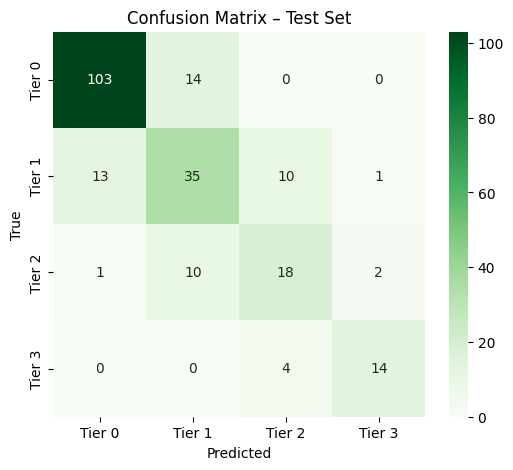

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"Tier {c}" for c in sorted(y.unique())],
            yticklabels=[f"Tier {c}" for c in sorted(y.unique())])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Test Set")
plt.show()


On the test set, the macro F1 score is about 0.703, and accuracy is 0.747. The confusion matrix shows Tier 1 and Tier 2 are the hardest to classify

# Error Analysis
1. Tier 1 and Tier 2 are the hardest to classify
2. They are often confused due to overlapping feature patterns
3. Tier 3 is sometimes predicted as Tier 2
This is concerning because it underestimates high-risk patient.

# Improvement

1. Use a class-weighted loss function
2. Assign higher weights to minority classes (especially Tier 3)
3. Penalize misclassification of high-risk patients more heavily
Helps the model focus on important but underrepresented classes.

This improves detection of high-risk cases, even if overall accuracy slightly decreases.

## Part F – Model Reliability
1.Confidence Vs Correctness

2.Reliability plot

3.Reliability Discussion

4.Real-World Risk of Overconfidence

In [ ]:
# Confidence Vs Correctness
max_conf = y_test_pred_proba.max(axis=1)
correct = (y_test_pred == y_test).astype(int)

import pandas as pd

df_conf = pd.DataFrame({
    "confidence": max_conf,
    "correct": correct
})

bins = [0.0, 0.5, 0.7, 0.85, 0.95, 1.0]
df_conf["conf_bin"] = pd.cut(df_conf["confidence"], bins=bins)

reliability = df_conf.groupby("conf_bin")["correct"].mean()
reliability


/tmp/ipykernel_227/2435455704.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reliability = df_conf.groupby("conf_bin")["correct"].mean()


,correct
conf_bin,
"(0.0, 0.5]",0.571429
"(0.5, 0.7]",0.604651
"(0.7, 0.85]",0.729730
"(0.85, 0.95]",0.843750
"(0.95, 1.0]",1.000000


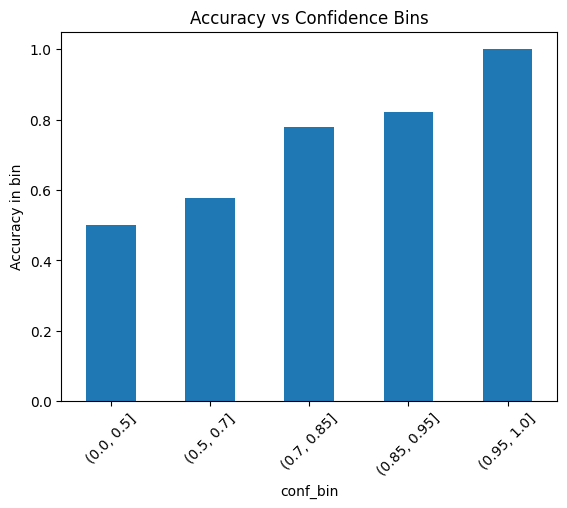

In [ ]:
# Reliability plot
reliability.plot(kind="bar", rot=45, ylabel="Accuracy in bin",
                 title="Accuracy vs Confidence Bins")
plt.show()


Finally, I generated a reliability plot. Higher confidence generally corresponds to higher correctness, which means the model is reasonably calibrated



**Real-World Risk of Overconfidence**

1. High-confidence wrong predictions can mislead users
2. For example: A patient predicted as healthy may miss early diagnosis
3. This can lead to delayed treatment and worse health outcomes




#a. Overfitting in the baseline model
In the baseline MLP, I saw clear overfitting.
- Training loss decreases continuously
-  Validation loss increases
- The training accuracy became very high, while
- validation accuracy stopped improving -
This indicates overfitting.

#b. Regularization effect
- Validation loss becomes stable

- Smaller gap between training and validation accuracy
Dropout reduces overfitting and improves generalization

# c. Accuracy is Misleading
- Dataset is imbalanced (Tier 0 majority)
- High accuracy can hide poor performance on high-risk classes
That’s why accuracy doesn’t reflect the real clinical impact

#d. Metric Choice
 I used macro Precision, macro Recall, and macro F1 score because
- Used macro Precision, Recall, F1-score Treats all classes equally
- Ensures fair evaluation of minority/high-risk classes


Overall, the dropout regularized MLP generalized better than the baseline model, and macro averaged metrics gave a fair evaluation across all tiers. The reliability analysis also showed that higher confidence generally meant higher correctness.
# Conclusion
- Dropout model generalizes better than baseline
- Macro metrics provide a more reliable evaluation
- Higher confidence generally leads to higher correctness